# Drone Detection — YOLOv11x Fine-tune (Kaggle GPU T4 x2)
**Detects:** Real outdoor drones + 3D printed indoor drones  
**Base model:** `doguilmak/Drone-Detection-YOLOv11x` — mAP@50=0.905 on real drones  
**Strategy:** Fine-tune on merged dataset (your 3D prints + backgrounds + outdoor drones)

---
### BEFORE RUNNING:
1. Right panel → **Accelerator: GPU T4 x2**
2. Right panel → **Internet: ON**
3. Paste your Roboflow API key in **Cell 2**

In [1]:
# ════════════════════════════════════════════════════════════
# CELL 1 — Install & verify GPU
# ════════════════════════════════════════════════════════════
!pip install ultralytics roboflow -q

import torch
from pathlib import Path

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
n_gpu = torch.cuda.device_count()
print(f'GPUs    : {n_gpu}')
for i in range(n_gpu):
    props = torch.cuda.get_device_properties(i)
    print(f'  [{i}] {props.name}  {props.total_memory // 1024**3} GB')

assert torch.cuda.is_available(), 'ERROR: No GPU — enable GPU T4 x2 in Session options'

DEVICE = '0,1' if n_gpu >= 2 else '0'
BATCH  = 32    if n_gpu >= 2 else 16
print(f'\n>>> Device={DEVICE}  Batch={BATCH}  — ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 63.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
PyTorch : 2.10.0+cu128
CUDA    : True
GPUs    : 2
  [0] Tesla T4  14 GB
  [1] Tesla T4  14 GB

>>> Device=0,1  Batch=32  — ready


In [2]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Download YOUR Roboflow dataset (auto latest version)
# ════════════════════════════════════════════════════════════
from roboflow import Roboflow
from pathlib import Path

API_KEY = 'ZaOMj2jVJyUuhkIiLYad'

rf      = Roboflow(api_key=API_KEY)
project = rf.workspace('fadils-workspace').project('drone-detection-puymg')

versions = project.versions()
latest   = max(versions, key=lambda v: v.version)
print(f'Found {len(versions)} version(s) — downloading latest: v{latest.version}')

dataset = latest.download('yolov8', location='/kaggle/working/custom')
print('\nDownloaded. Structure:')
!find /kaggle/working/custom -type d | sort

loading Roboflow workspace...
loading Roboflow project...
Found 3 version(s) — downloading latest: v3



Extracting Dataset Version Zip to /kaggle/working/custom in yolov8:: 100%|██████████| 2121/2121 [00:00<00:00, 9199.89it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



Downloaded. Structure:
/kaggle/working/custom
/kaggle/working/custom/test
/kaggle/working/custom/test/images
/kaggle/working/custom/test/labels
/kaggle/working/custom/train
/kaggle/working/custom/train/images
/kaggle/working/custom/train/labels
/kaggle/working/custom/valid
/kaggle/working/custom/valid/images
/kaggle/working/custom/valid/labels


In [3]:
# ════════════════════════════════════════════════════════════
# CELL 3 — Download outdoor drone dataset from Kaggle
# ════════════════════════════════════════════════════════════
import subprocess

r = subprocess.run(
    ['kaggle', 'datasets', 'download',
     '-d', 'muki2003/yolo-drone-detection-dataset',
     '-p', '/kaggle/working/outdoor', '--unzip'],
    capture_output=True, text=True
)
print(r.stdout or '(no stdout)')
if r.returncode != 0:
    print('STDERR:', r.stderr)
    print('WARNING: outdoor dataset failed — training on custom data only (still fine)')
else:
    print('Outdoor dataset downloaded OK')
    !find /kaggle/working/outdoor -type d | sort

Dataset URL: https://www.kaggle.com/datasets/muki2003/yolo-drone-detection-dataset
License(s): other


Outdoor dataset downloaded OK
/kaggle/working/outdoor
/kaggle/working/outdoor/drone_dataset
/kaggle/working/outdoor/drone_dataset/train
/kaggle/working/outdoor/drone_dataset/train/images
/kaggle/working/outdoor/drone_dataset/train/labels
/kaggle/working/outdoor/drone_dataset/valid
/kaggle/working/outdoor/drone_dataset/valid/images
/kaggle/working/outdoor/drone_dataset/valid/labels


In [4]:
# ════════════════════════════════════════════════════════════
# CELL 4 — Merge all datasets into one
# ════════════════════════════════════════════════════════════
import shutil
from pathlib import Path

MERGED = Path('/kaggle/working/merged')
for split in ['train', 'valid']:
    (MERGED / split / 'images').mkdir(parents=True, exist_ok=True)
    (MERGED / split / 'labels').mkdir(parents=True, exist_ok=True)

def copy_split(img_dir, lbl_dir, dst_split, tag):
    img_dir, lbl_dir = Path(img_dir), Path(lbl_dir)
    if not img_dir.exists():
        print(f'  SKIP: {img_dir} does not exist')
        return 0
    copied = 0
    for img in img_dir.glob('*'):
        if img.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp'}:
            continue
        dst_img = MERGED / dst_split / 'images' / f'{tag}_{img.name}'
        dst_lbl = MERGED / dst_split / 'labels' / f'{tag}_{img.stem}.txt'
        shutil.copy(img, dst_img)
        lbl = lbl_dir / (img.stem + '.txt')
        if lbl.exists():
            shutil.copy(lbl, dst_lbl)
        else:
            dst_lbl.write_text('')  # background — empty label
        copied += 1
    return copied

# ── 1. Custom dataset (3D drones + backgrounds) ──────────────
CUSTOM = Path('/kaggle/working/custom')
# Handle both possible Roboflow structures
custom_train_imgs = CUSTOM / 'train' / 'images'
custom_valid_imgs = CUSTOM / 'valid' / 'images'
if not custom_train_imgs.exists():
    # Try alternative: images directly in split folder
    custom_train_imgs = CUSTOM / 'train'
    custom_valid_imgs = CUSTOM / 'valid'

n  = copy_split(custom_train_imgs, custom_train_imgs.parent / 'labels', 'train', 'c')
n += copy_split(custom_valid_imgs, custom_valid_imgs.parent / 'labels', 'valid', 'c')
print(f'Custom dataset  : {n} images')

# ── 2. Outdoor drones (auto-detect structure) ─────────────────
OUTDOOR = Path('/kaggle/working/outdoor')
outdoor_total = 0
if OUTDOOR.exists():
    img_dirs = [p for p in OUTDOOR.rglob('images') if p.is_dir()]
    if not img_dirs:
        img_dirs = [OUTDOOR]
    for img_dir in img_dirs:
        parent = img_dir.parent.name.lower()
        dst = 'valid' if ('val' in parent or 'test' in parent) else 'train'
        lbl_dir = img_dir.parent / 'labels'
        if not lbl_dir.exists():
            lbl_dir = img_dir.parent.parent / 'labels' / img_dir.parent.name
        if not lbl_dir.exists():
            lbl_dir = img_dir
        k = copy_split(img_dir, lbl_dir, dst, 'o')
        outdoor_total += k
        if k > 0:
            print(f'  Outdoor [{dst}]: {k} images from {img_dir}')

print(f'Outdoor dataset : {outdoor_total} images')

tr = len(list((MERGED/'train'/'images').glob('*')))
va = len(list((MERGED/'valid'/'images').glob('*')))
print(f'\nMERGED TOTAL → train: {tr}  |  valid: {va}')

Custom dataset  : 1027 images
  Outdoor [valid]: 347 images from /kaggle/working/outdoor/drone_dataset/valid/images
  Outdoor [train]: 1012 images from /kaggle/working/outdoor/drone_dataset/train/images
Outdoor dataset : 1359 images

MERGED TOTAL → train: 1978  |  valid: 408


In [5]:
# ════════════════════════════════════════════════════════════
# CELL 5 — Convert polygon labels → bounding boxes + fix class IDs
# (Roboflow exported polygon segmentation format — converting to YOLO detection)
# ════════════════════════════════════════════════════════════
from pathlib import Path

converted = 0
fixed_cls = 0
empty     = 0

for lbl in Path('/kaggle/working/merged').rglob('*.txt'):
    lines = lbl.read_text().strip().splitlines()
    new_lines = []

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue  # skip malformed

        cls = '0'  # force class 0
        if parts[0] != '0':
            fixed_cls += 1

        values = list(map(float, parts[1:]))

        if len(values) == 4:
            # Already bounding box format: x_center y_center w h
            new_lines.append(f'{cls} {values[0]:.6f} {values[1]:.6f} {values[2]:.6f} {values[3]:.6f}')

        elif len(values) >= 6 and len(values) % 2 == 0:
            # Polygon format: x1 y1 x2 y2 ... → convert to bbox
            xs = values[0::2]
            ys = values[1::2]
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            x_center = (x_min + x_max) / 2
            y_center = (y_min + y_max) / 2
            width    = x_max - x_min
            height   = y_max - y_min
            # Clamp to [0,1]
            x_center = max(0.0, min(1.0, x_center))
            y_center = max(0.0, min(1.0, y_center))
            width    = max(0.001, min(1.0, width))
            height   = max(0.001, min(1.0, height))
            new_lines.append(f'{cls} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}')
            converted += 1

    if not new_lines:
        empty += 1

    lbl.write_text('\n'.join(new_lines))

print(f'Polygon → bbox conversions : {converted}')
print(f'Class ID fixes             : {fixed_cls}')
print(f'Empty labels (backgrounds) : {empty}')
print('All labels now in YOLO detection format  ✓')

# Write data.yaml
yaml = """train: /kaggle/working/merged/train/images
val: /kaggle/working/merged/valid/images
nc: 1
names: ['drone']
"""
Path('/kaggle/working/merged/data.yaml').write_text(yaml)
print('\ndata.yaml written ✓')

Polygon → bbox conversions : 807
Class ID fixes             : 0
Empty labels (backgrounds) : 321
All labels now in YOLO detection format  ✓

data.yaml written ✓


In [6]:
# ════════════════════════════════════════════════════════════
# CELL 6 — Download pre-trained YOLOv11x drone weights
# doguilmak/Drone-Detection-YOLOv11x — mAP@50=0.905 on real drones
# ════════════════════════════════════════════════════════════
from pathlib import Path

!wget -q --show-progress \
    'https://huggingface.co/doguilmak/Drone-Detection-YOLOv11x/resolve/main/weight/best.pt?download=true' \
    -O /kaggle/working/pretrained.pt

sz = Path('/kaggle/working/pretrained.pt').stat().st_size / 1e6
assert sz > 50, f'Download failed — file too small: {sz:.1f} MB'
print(f'Pretrained weights: {sz:.1f} MB  ✓')

/kaggle/working/pre 100%[===================>] 109.08M  32.7MB/s    in 3.3s    
Pretrained weights: 114.4 MB  ✓


In [7]:
# ════════════════════════════════════════════════════════════
# CELL 7 — TRAIN
# ════════════════════════════════════════════════════════════
from ultralytics import YOLO

model = YOLO('/kaggle/working/pretrained.pt')

model.train(
    # Data
    data         = '/kaggle/working/merged/data.yaml',
    imgsz        = 640,
    batch        = BATCH,
    epochs       = 80,
    patience     = 20,

    # Hardware
    device       = DEVICE,
    workers      = 4,

    # Fine-tune
    freeze       = 10,
    lr0          = 0.0005,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 0.0005,
    warmup_epochs= 3,
    close_mosaic = 15,

    # Augmentation
    degrees      = 45,
    translate    = 0.1,
    scale        = 0.5,
    fliplr       = 0.5,
    flipud       = 0.2,
    mosaic       = 1.0,
    mixup        = 0.15,
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    erasing      = 0.3,

    # Output
    project      = '/kaggle/working/runs',
    name         = 'drone_final',
    exist_ok     = True,
    save         = True,
    save_period  = 10,
    plots        = True,
    verbose      = True,
)

print('\n' + '='*50)
print('TRAINING COMPLETE')
print('='*50)

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/merged/data.yaml, degrees=45, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=/kaggle/working/pretrained.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name

libpng warning: iCCP: known incorrect sRGB profile


       1/80      7.01G      2.124      2.155      2.345         35        640: 40% ━━━━╸─────── 25/62 1.3it/s 28.7s<28.3s

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


       1/80      7.01G      2.031       2.05      2.268         34        640: 58% ━━━━━━╸───── 36/62 1.3it/s 37.2s<20.0s

...

      80/80      6.79G     0.9699     0.5507      1.432         15        640: 40% ━━━━╸─────── 25/62 1.2it/s 21.7s<30.8s

libpng warning: iCCP: known incorrect sRGB profile


      80/80      6.79G     0.9477     0.5431      1.411         14        640: 73% ━━━━━━━━╸─── 45/62 1.2it/s 38.5s<14.2s

libpng warning: iCCP: known incorrect sRGB profile


      80/80      6.79G     0.9461     0.5418      1.411         13        640: 100% ━━━━━━━━━━━━ 62/62 1.2it/s 51.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.6it/s 4.4s
                   all        408        433       0.93      0.857      0.913      0.563

80 epochs completed in 1.332 hours.
Optimizer stripped from /kaggle/working/runs/drone_final/weights/last.pt, 114.4MB
Optimizer stripped from /kaggle/working/runs/drone_final/weights/best.pt, 114.4MB

Validating /kaggle/working/runs/drone_final/weights/best.pt...
YOLO11x summary (fused): 191 layers, 56,828,179 parameters, 0 gradients, 194.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.4it/s 5.0s
                   all        408        433      0.932      0.857      0.913      0.564
Speed: 0.1ms preprocess, 8.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kagg

In [8]:
# ════════════════════════════════════════════════════════════
# CELL 8 — Validate final model
# ════════════════════════════════════════════════════════════
from ultralytics import YOLO

best = YOLO('/kaggle/working/runs/drone_final/weights/best.pt')
m = best.val(data='/kaggle/working/merged/data.yaml', imgsz=640, verbose=False)

print('\n════ FINAL MODEL METRICS ════')
print(f'  mAP@50     : {m.box.map50:.4f}')
print(f'  mAP@50-95  : {m.box.map:.4f}')
print(f'  Precision  : {m.box.mp:.4f}')
print(f'  Recall     : {m.box.mr:.4f}')
print('════════════════════════════')

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11x summary (fused): 191 layers, 56,828,179 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1973.9±1290.7 MB/s, size: 248.0 KB)
val: Scanning /kaggle/working/merged/valid/labels.cache... 408 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 408/408 81.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 1.1it/s 24.2s
                   all        408        433      0.933      0.857      0.914      0.563
Speed: 0.6ms preprocess, 55.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

════ FINAL MODEL METRICS ════
  mAP@50     : 0.9136
  mAP@50-95  : 0.5631
  Precision  : 0.9335
  Recall     : 0.8568
════════════════════════════



── results.png ──


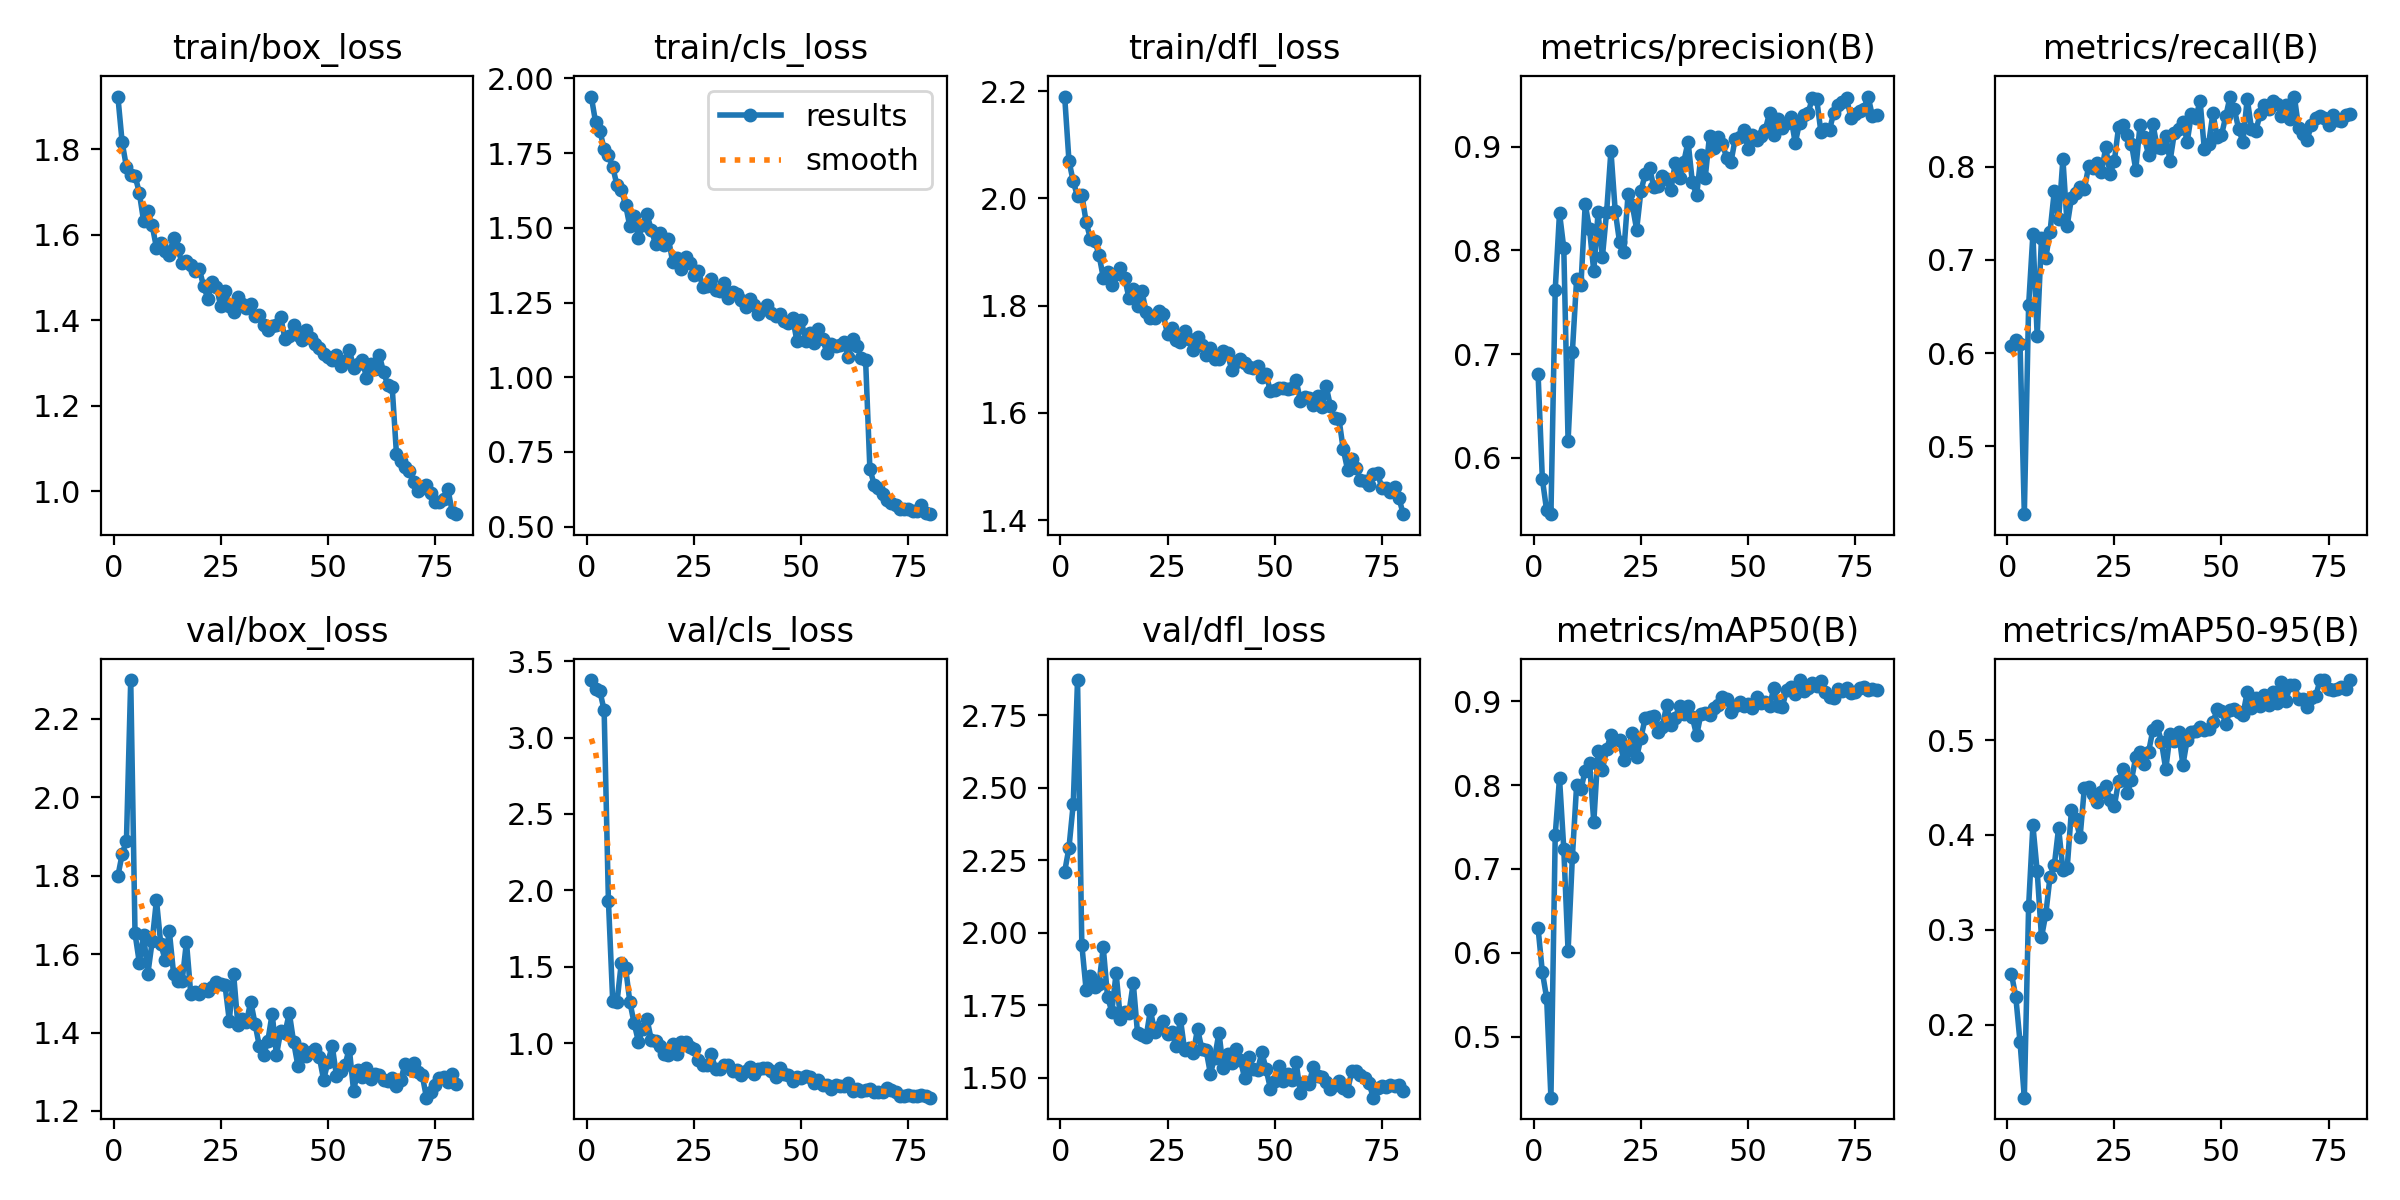


── confusion_matrix_normalized.png ──


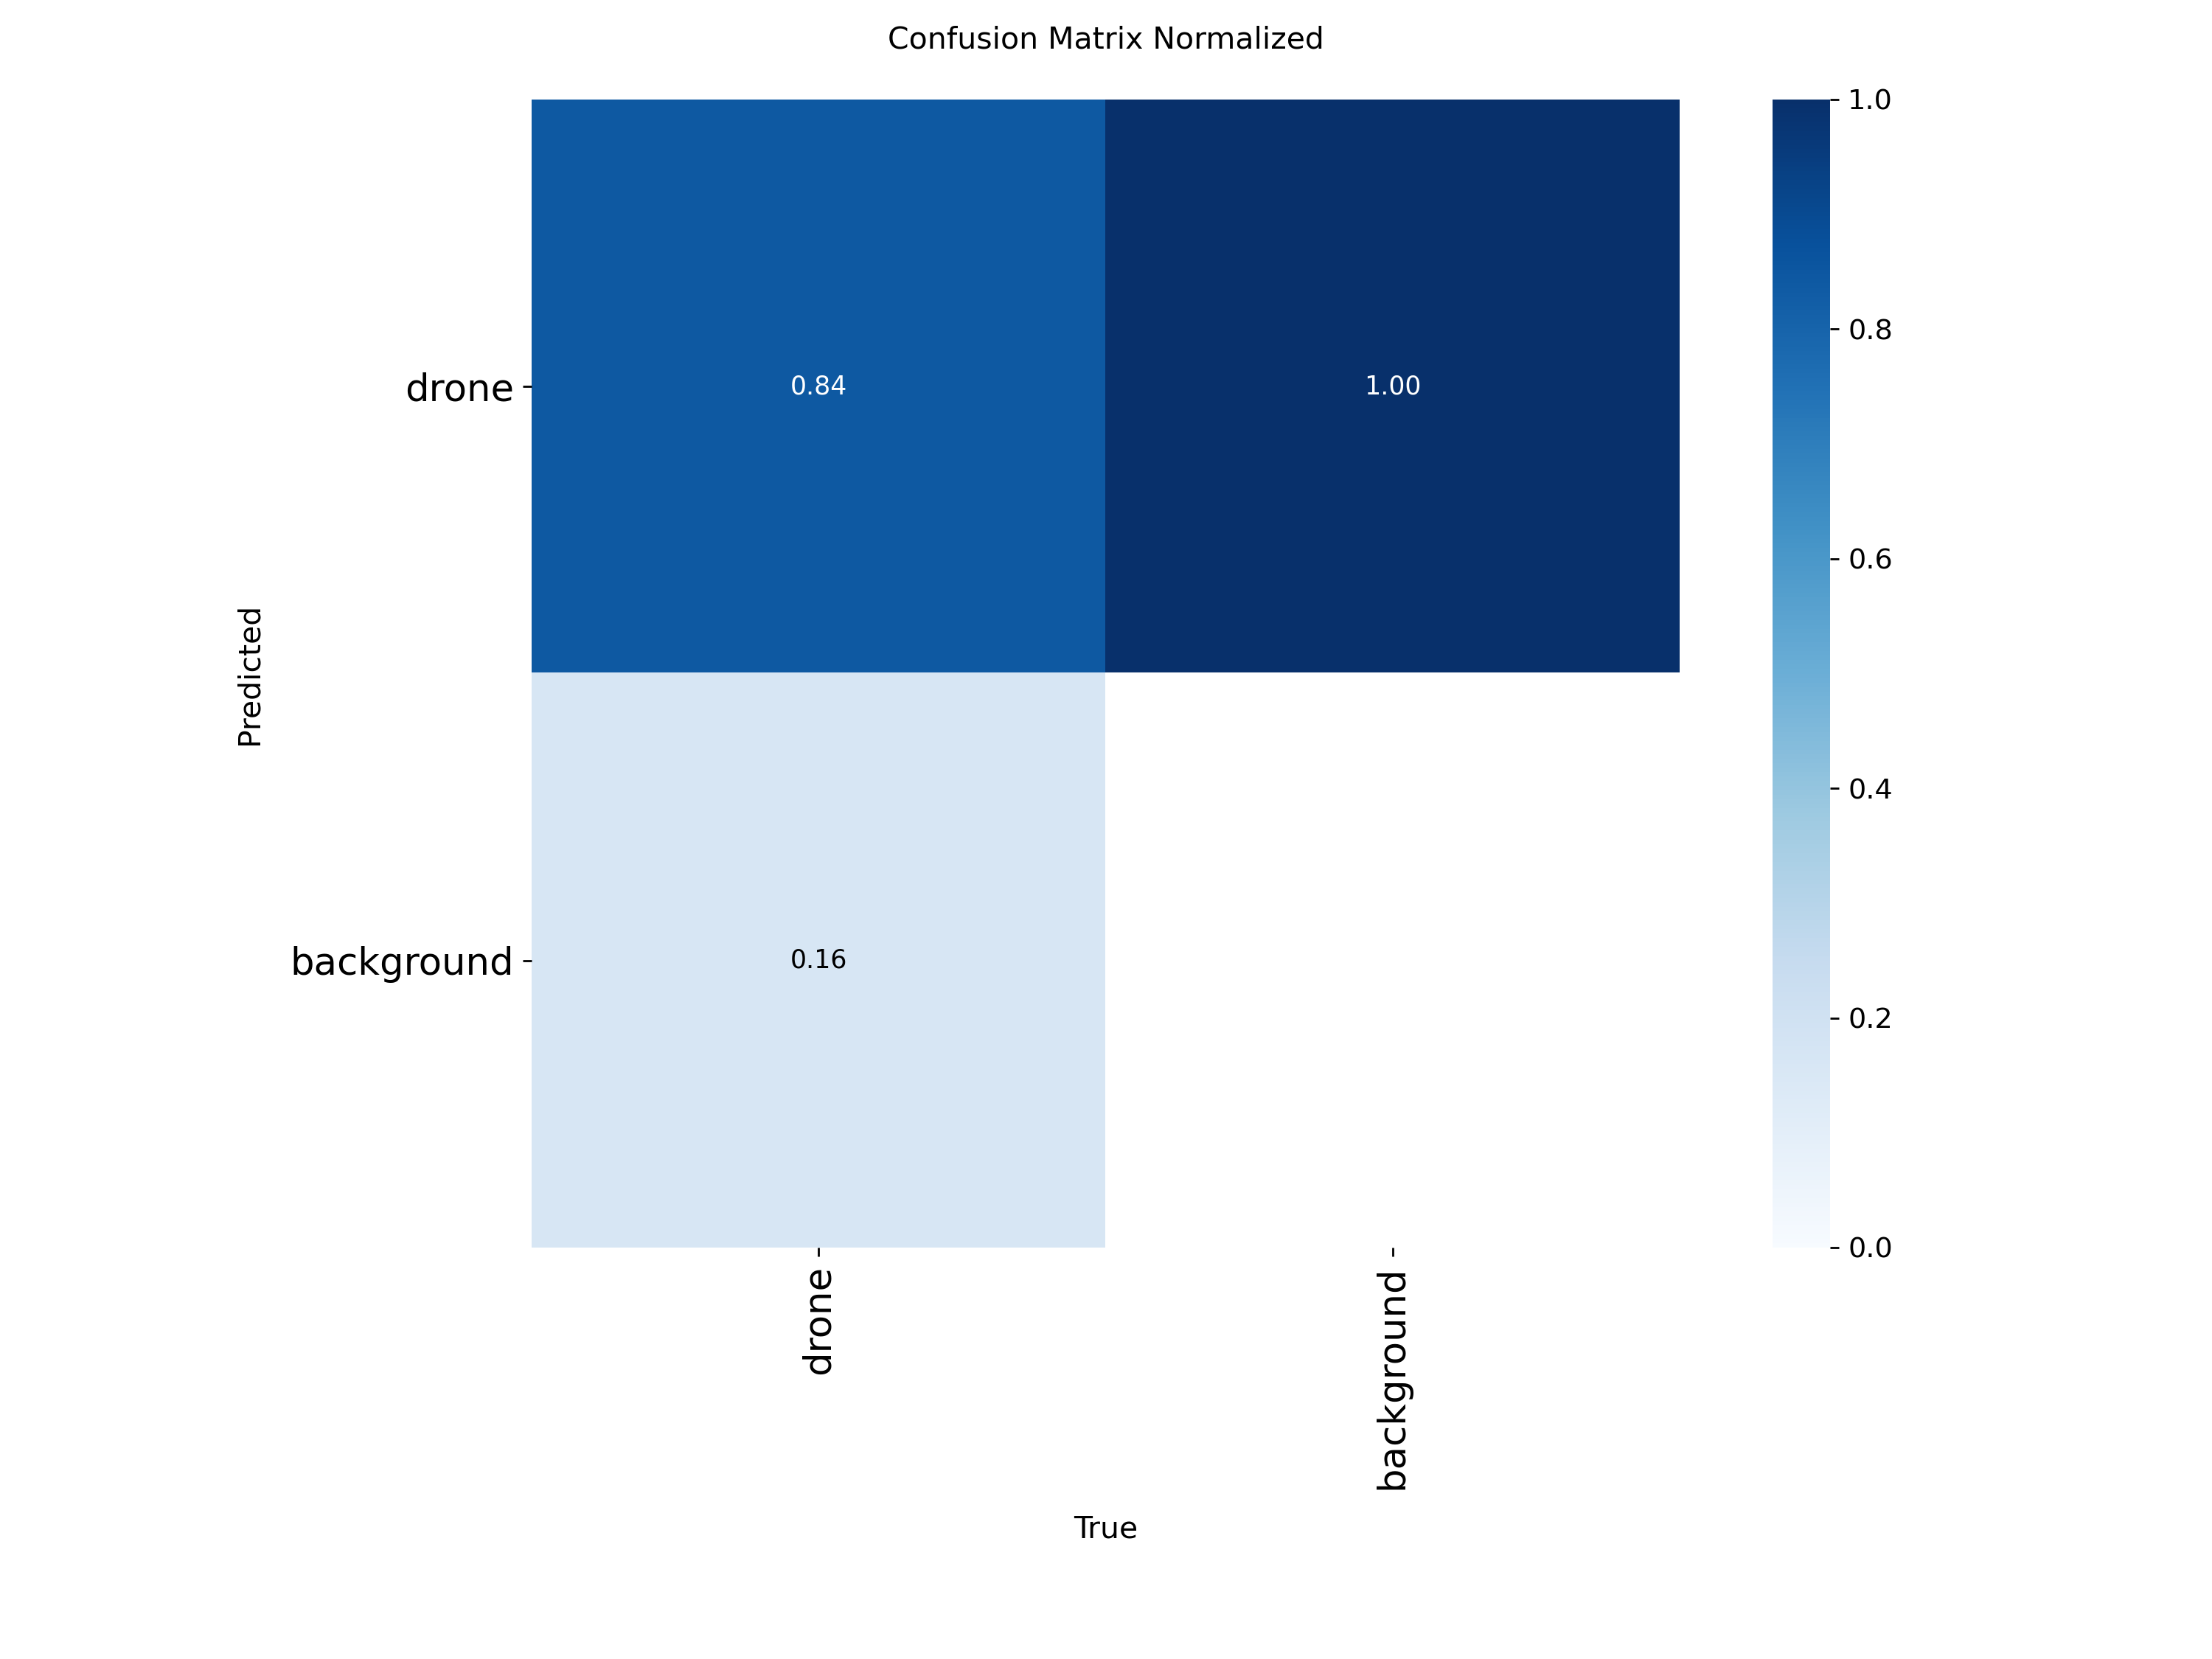


── val_batch0_pred.jpg ──


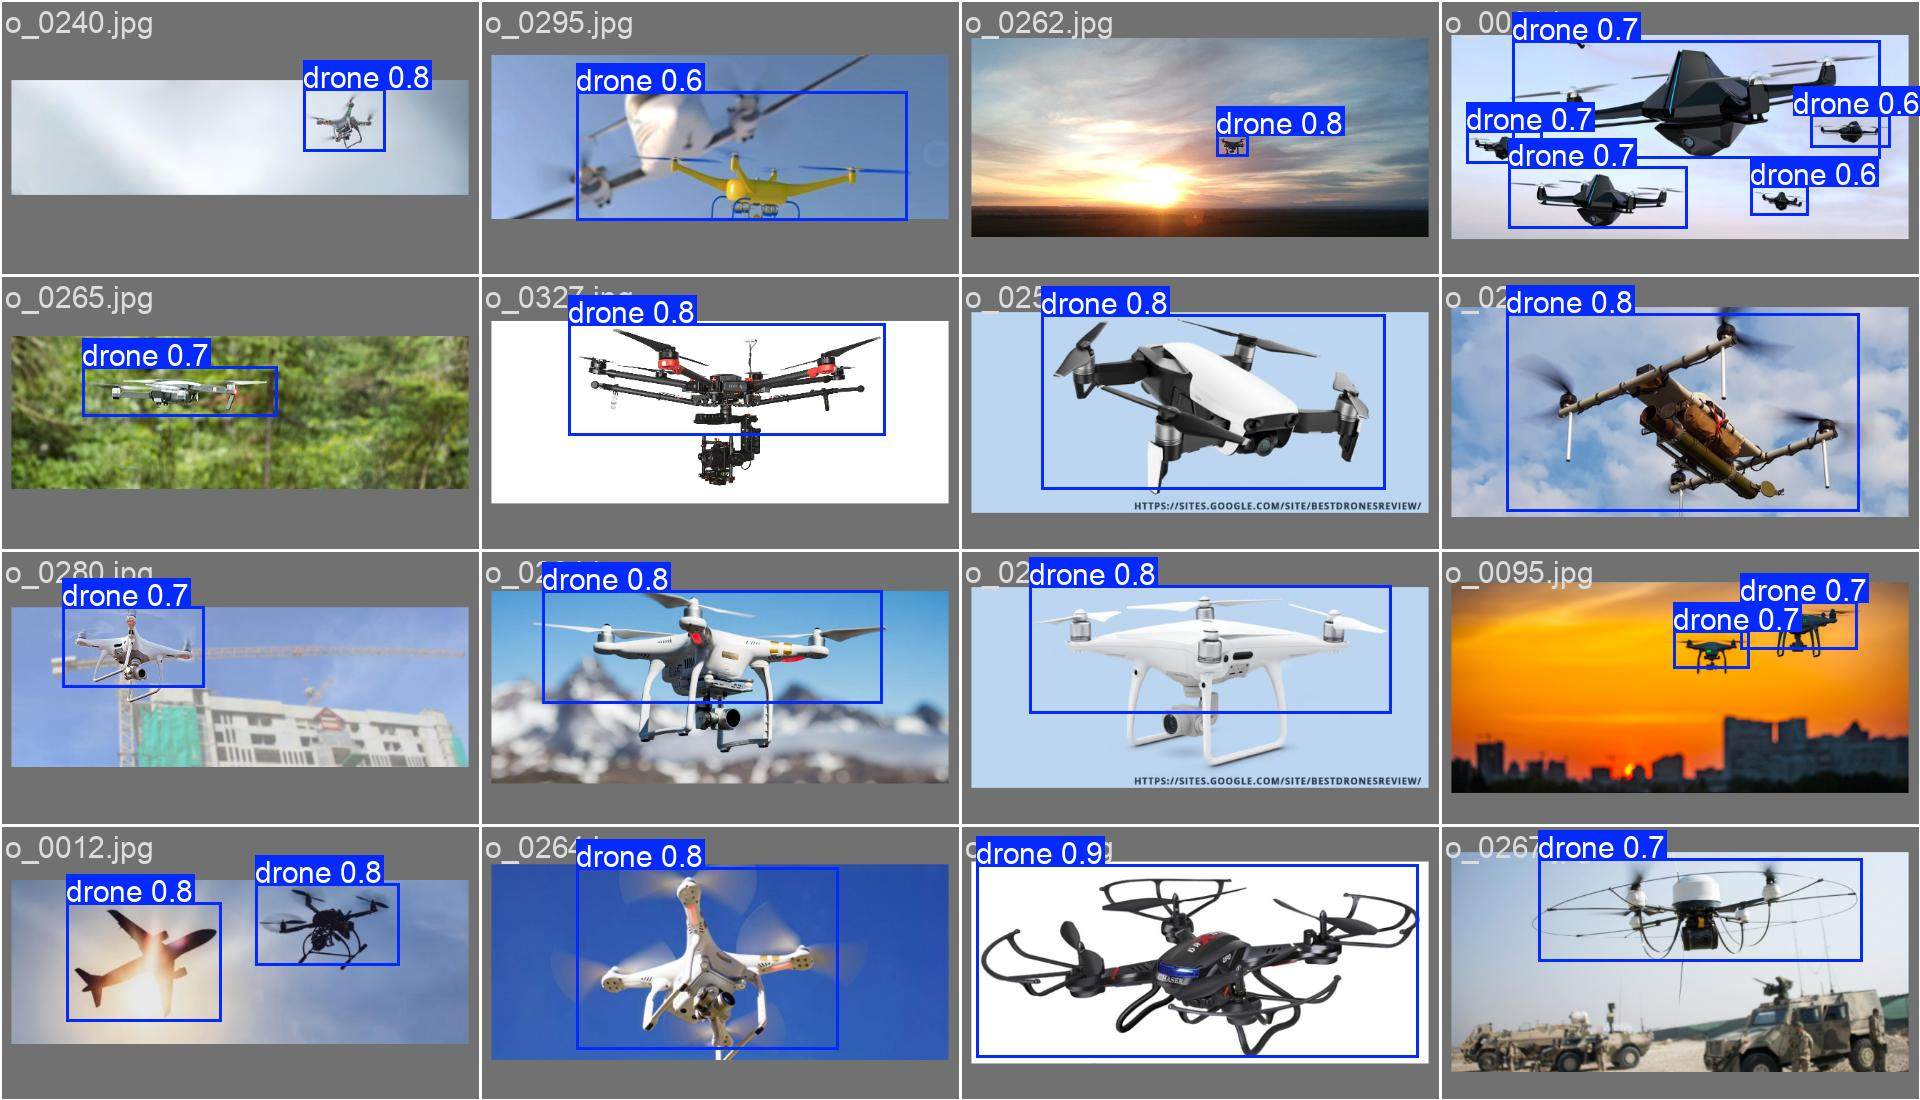

In [9]:
# ════════════════════════════════════════════════════════════
# CELL 9 — Show training curves
# ════════════════════════════════════════════════════════════
from IPython.display import Image, display
from pathlib import Path

run = Path('/kaggle/working/runs/drone_final')
for fname in ['results.png', 'confusion_matrix_normalized.png', 'val_batch0_pred.jpg']:
    p = run / fname
    if not p.exists():
        p = run / fname.replace('_normalized', '')
    if p.exists():
        print(f'\n── {fname} ──')
        display(Image(str(p), width=900))
    else:
        print(f'Not found: {fname}')

Results saved to /kaggle/working/test_preds/run
[OUTDOOR] o_pic_007.jpg


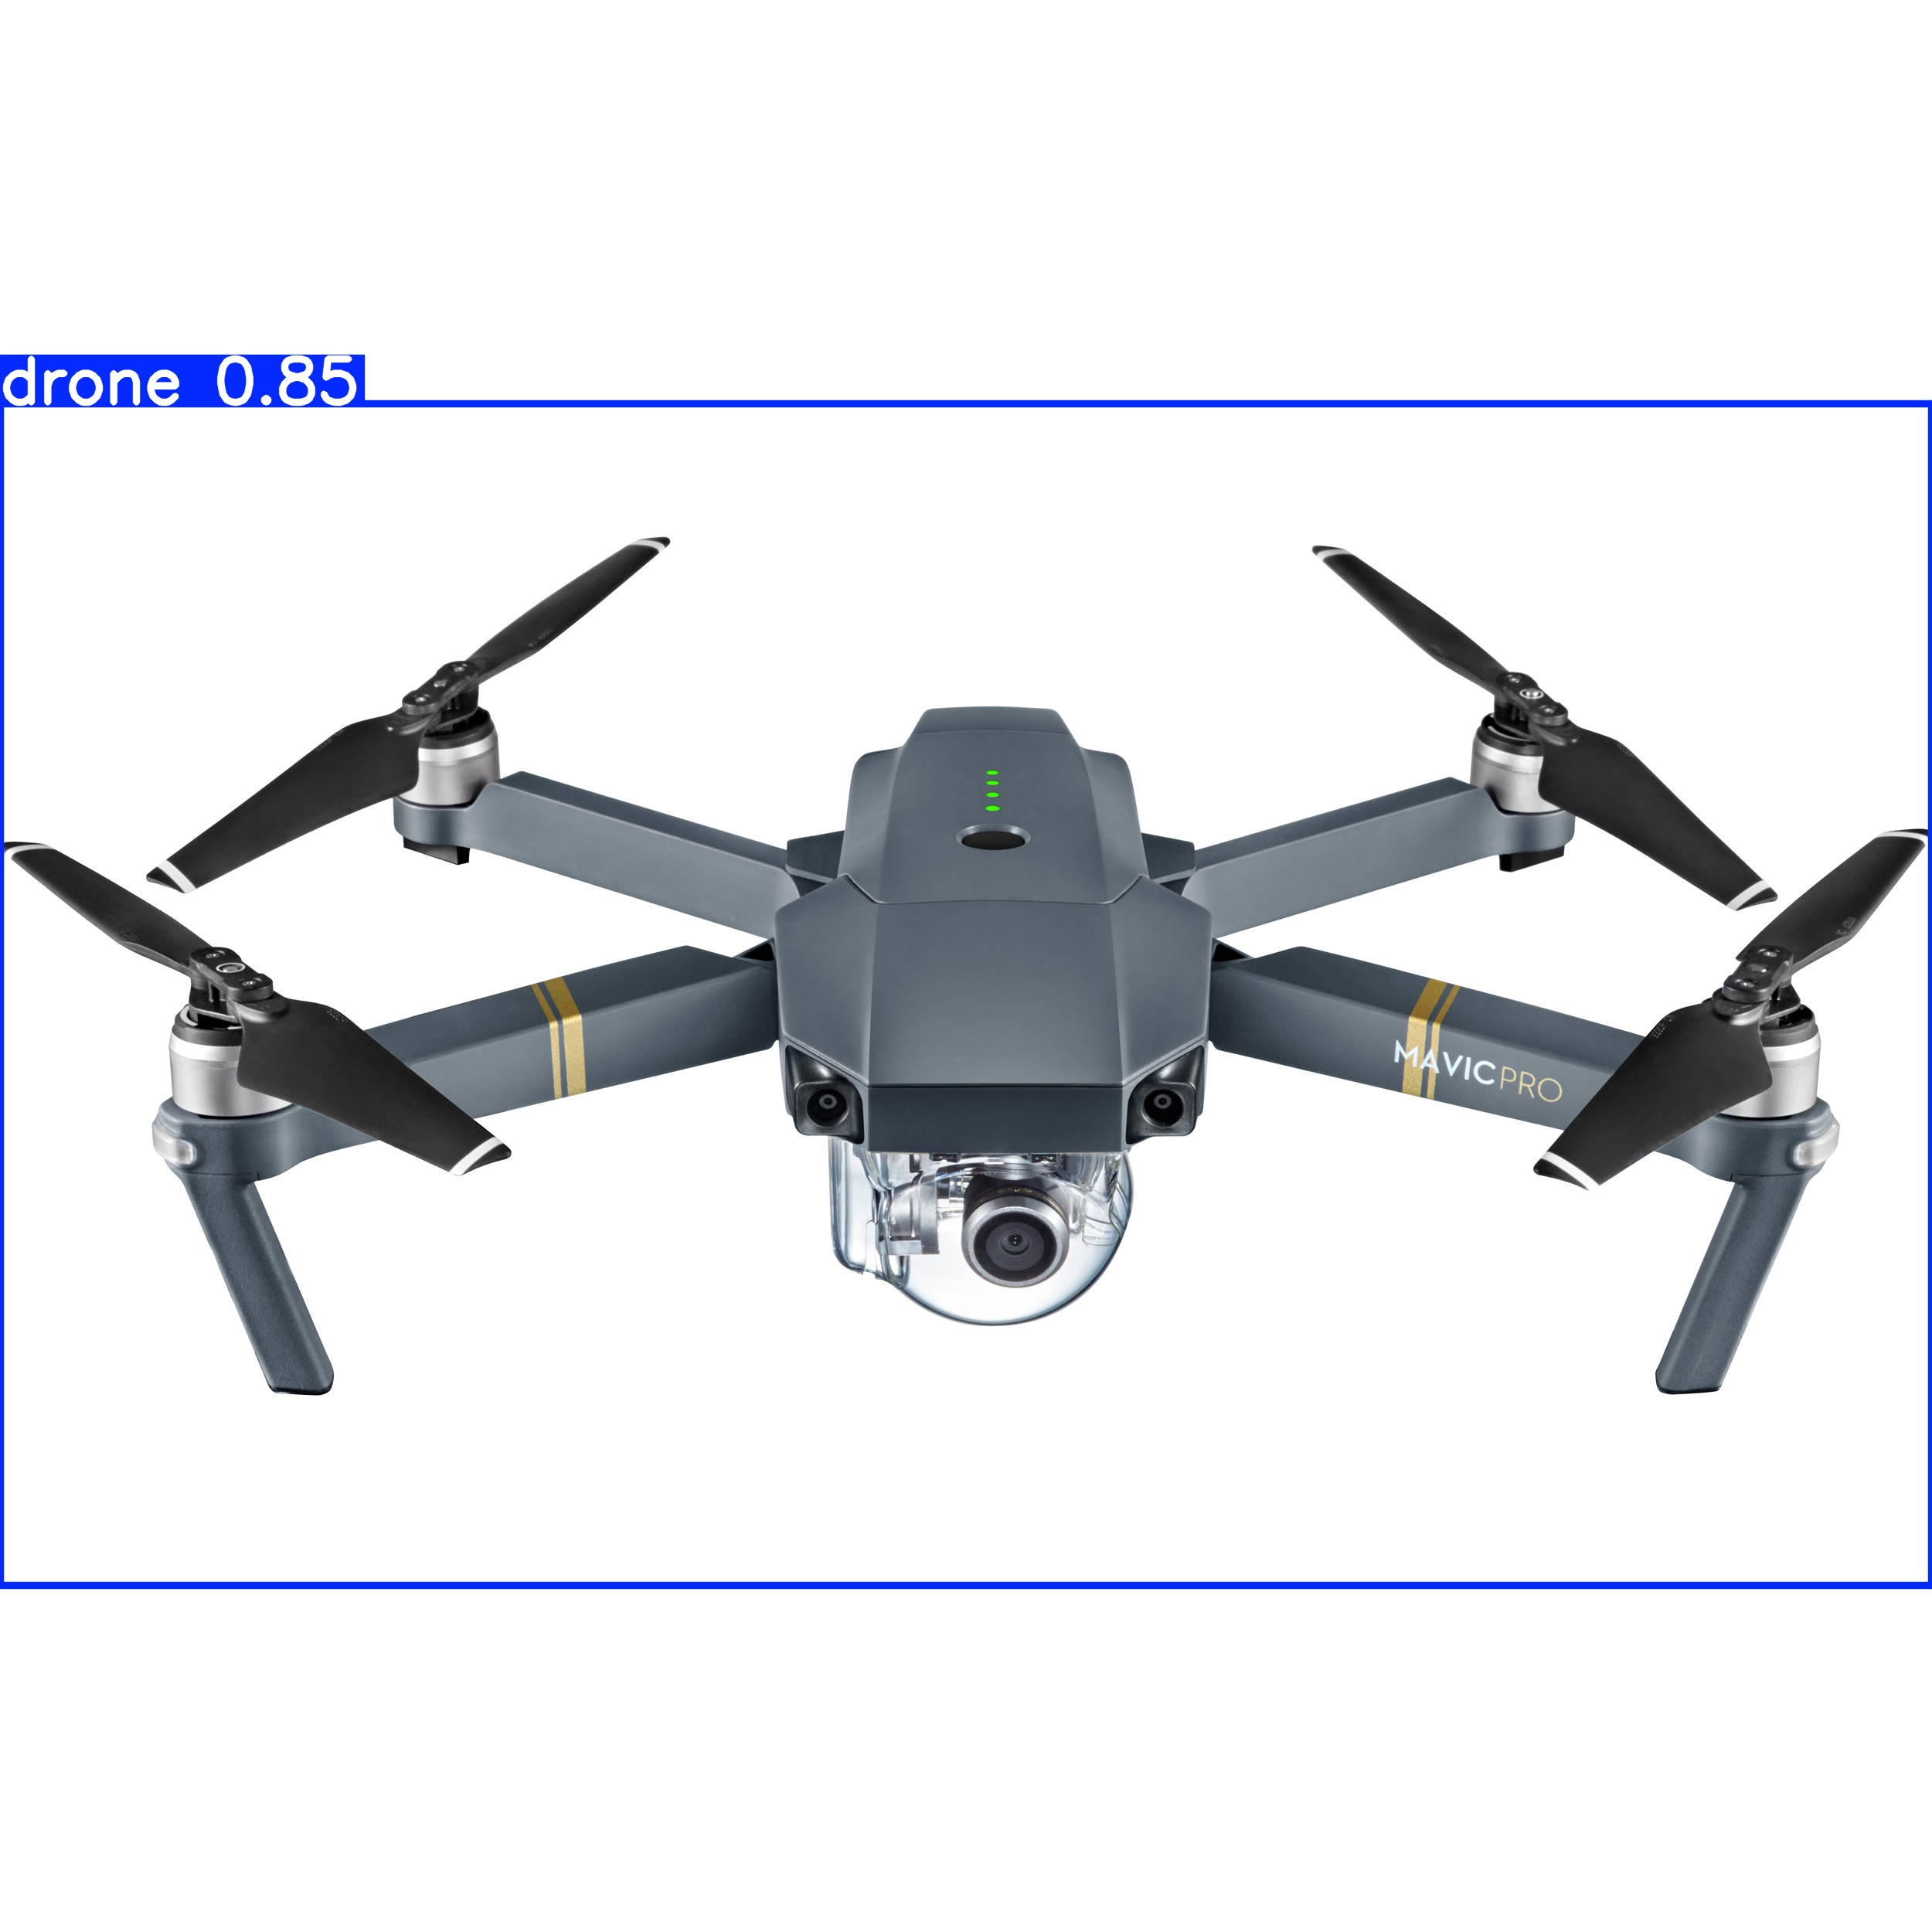

Results saved to /kaggle/working/test_preds/run
[OUTDOOR] o_pic_024.jpg


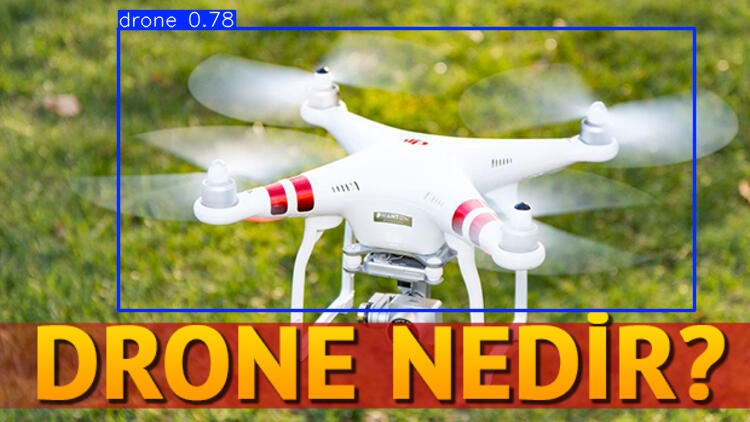

Results saved to /kaggle/working/test_preds/run
[OUTDOOR] o_0056.jpg


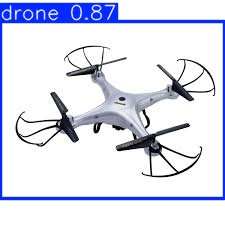

Results saved to /kaggle/working/test_preds/run
[OUTDOOR] o_0215.jpg


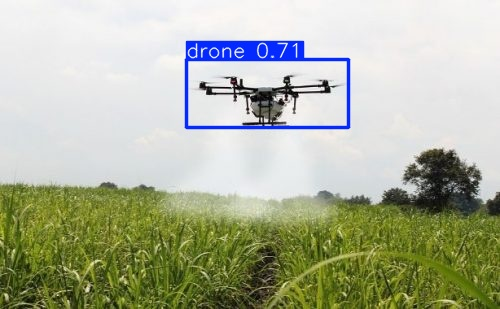

Results saved to /kaggle/working/test_preds/run
[OUTDOOR] o_0223.jpg


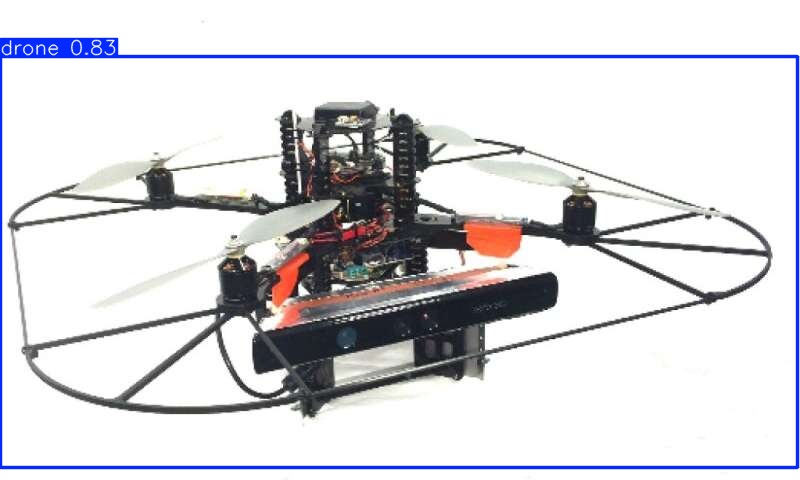

Results saved to /kaggle/working/test_preds/run
[CUSTOM-3D] c_drone_img_1776928009_jpg.rf.0c64837b6a7e963ff7e05c84146fbe48.jpg


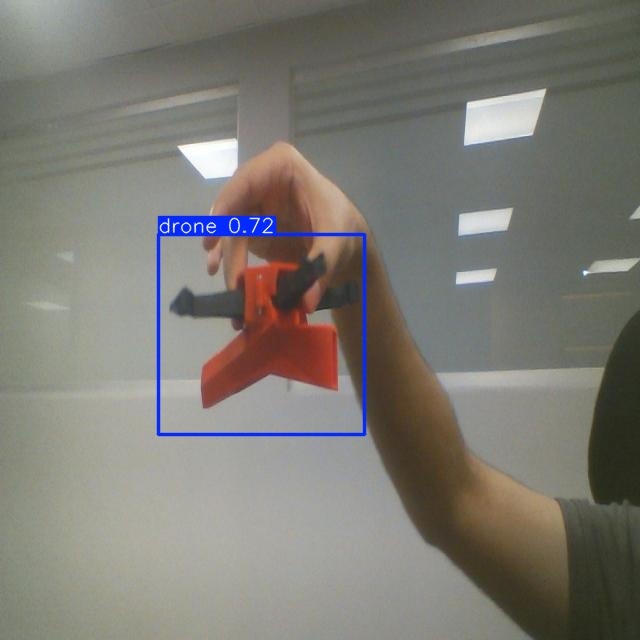

Results saved to /kaggle/working/test_preds/run
[OUTDOOR] o_foto04931.jpg


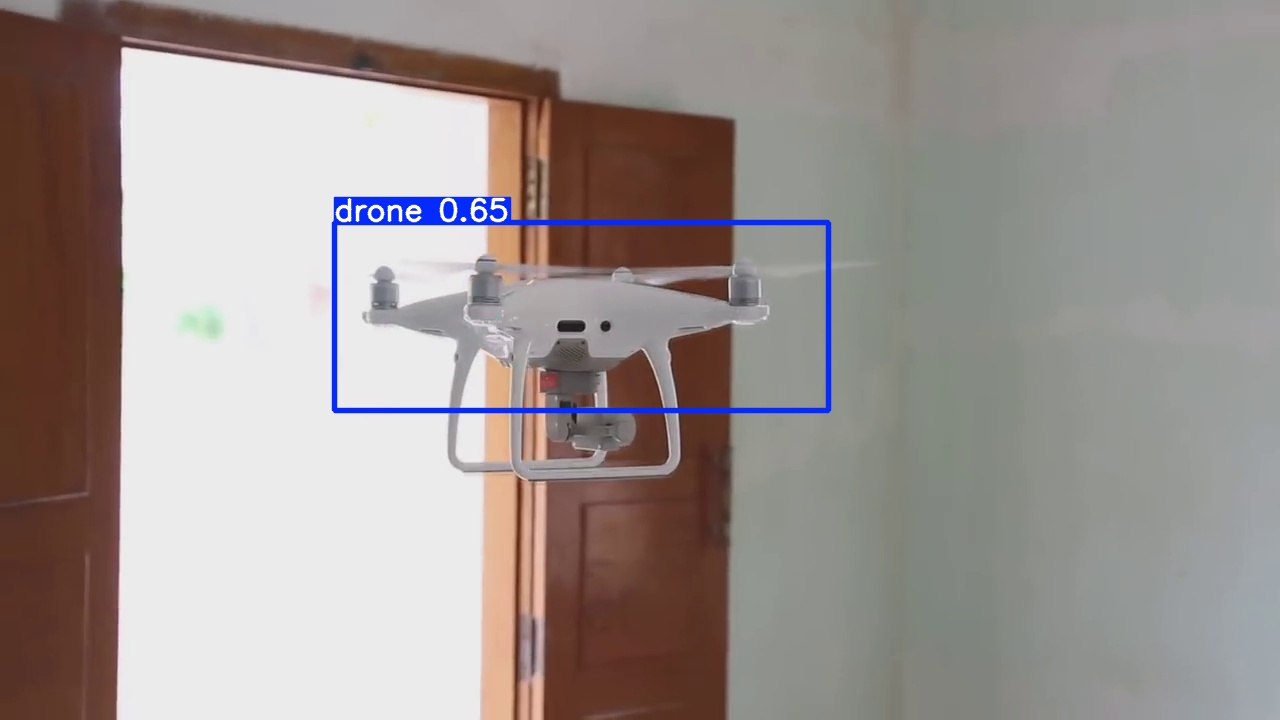

Results saved to /kaggle/working/test_preds/run
[CUSTOM-3D] c_drone_img_1776927993_jpg.rf.1548c2cd25dbf655a32270427f310c65.jpg


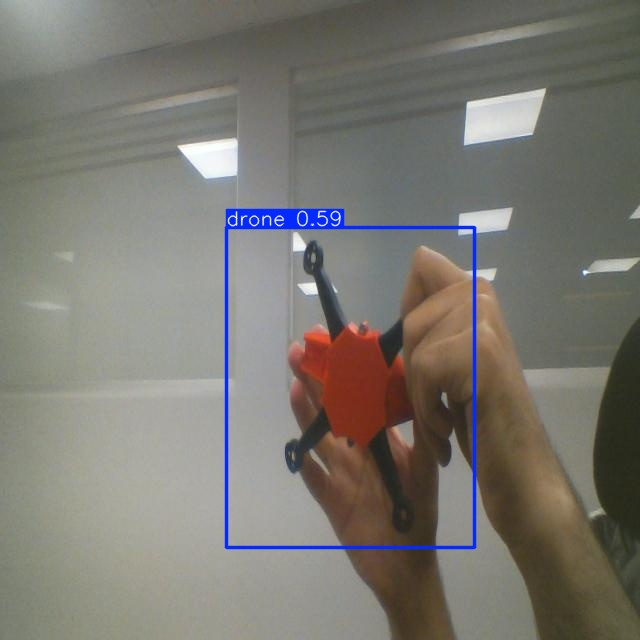

In [10]:
# ════════════════════════════════════════════════════════════
# CELL 10 — Visual test on validation images
# ════════════════════════════════════════════════════════════
from ultralytics import YOLO
from IPython.display import Image, display
from pathlib import Path
import random

best = YOLO('/kaggle/working/runs/drone_final/weights/best.pt')

val_imgs = list(Path('/kaggle/working/merged/valid/images').glob('*'))
sample   = random.sample(val_imgs, min(8, len(val_imgs)))

out_dir = Path('/kaggle/working/test_preds')
out_dir.mkdir(exist_ok=True)

for img_path in sample:
    results = best.predict(
        str(img_path), conf=0.35,
        save=True, project=str(out_dir), name='run',
        exist_ok=True, verbose=False
    )
    saved = sorted((out_dir / 'run').glob('*.jpg'), key=lambda p: p.stat().st_mtime)
    if saved:
        tag = 'CUSTOM-3D' if img_path.name.startswith('c_') else 'OUTDOOR'
        print(f'[{tag}] {img_path.name}')
        display(Image(str(saved[-1]), width=640))

In [11]:
# ════════════════════════════════════════════════════════════
# CELL 11 — Export to NCNN (Raspberry Pi — 3-4x faster)
# ════════════════════════════════════════════════════════════
from ultralytics import YOLO

best = YOLO('/kaggle/working/runs/drone_final/weights/best.pt')
best.export(format='ncnn', imgsz=640)

print('NCNN export done.')
!ls /kaggle/working/runs/drone_final/weights/

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ NCNN export does not support end2end models, disabling end2end branch.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11x summary (fused): 191 layers, 56,828,179 parameters, 0 gradients, 194.4 GFLOPs

PyTorch: starting from '/kaggle/working/runs/drone_final/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (109.1 MB)
requirements: Ultralytics requirement ['ncnn'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 1 package in 103ms
 Downloaded ncnn
Prepared 1 package in 1.07s
Installed 1 package in 7ms
 + ncnn==1.0.20260114

requirements: AutoUpdate success ✅ 1.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics requirement ['pnnx'] not found, attempting Aut

pnnxparam = /kaggle/working/runs/drone_final/weights/best_ncnn_model/model.pnnx.param
pnnxbin = /kaggle/working/runs/drone_final/weights/best_ncnn_model/model.pnnx.bin
pnnxpy = /kaggle/working/runs/drone_final/weights/best_ncnn_model/model_pnnx.py
pnnxonnx = /kaggle/working/runs/drone_final/weights/best_ncnn_model/model.pnnx.onnx
ncnnparam = /kaggle/working/runs/drone_final/weights/best_ncnn_model/model.ncnn.param
ncnnbin = /kaggle/working/runs/drone_final/weights/best_ncnn_model/model.ncnn.bin
ncnnpy = /kaggle/working/runs/drone_final/weights/best_ncnn_model/model_ncnn.py
fp16 = 0
optlevel = 2
device = cpu
inputshape = [1,3,640,640]f32
inputshape2 = 
customop = 
moduleop = 
get inputshape from traced inputs
inputshape = [1,3,640,640]f32
############# pass_level0
inline module = torch.nn.modules.linear.Identity
inline module = ultralytics.nn.modules.block.Attention
inline module = ultralytics.nn.modules.block.Bottleneck
inline module = ultralytics.nn.modules.block.C2PSA
inline module =

NCNN: export success ✅ 51.1s, saved as '/kaggle/working/runs/drone_final/weights/best_ncnn_model' (217.0 MB)

Export complete (55.2s)
Results saved to /kaggle/working/runs/drone_final/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs/drone_final/weights/best_ncnn_model imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/drone_final/weights/best_ncnn_model imgsz=640 data=/kaggle/working/merged/data.yaml  
Visualize:       https://netron.app
NCNN export done.
best_ncnn_model  epoch0.pt   epoch20.pt  epoch40.pt  epoch60.pt  last.pt
best.pt		 epoch10.pt  epoch30.pt  epoch50.pt  epoch70.pt


In [12]:
# ════════════════════════════════════════════════════════════
# CELL 12 — Zip all weights & auto-download to your computer
# ════════════════════════════════════════════════════════════
import shutil
from pathlib import Path
from IPython.display import FileLink, display

weights_dir = Path('/kaggle/working/runs/drone_final/weights')
shutil.make_archive('/kaggle/working/drone_models', 'zip', str(weights_dir))

sz = Path('/kaggle/working/drone_models.zip').stat().st_size / 1e6
print(f'drone_models.zip  →  {sz:.1f} MB')
print('\nContents:')
!ls -lh /kaggle/working/runs/drone_final/weights/

# Auto-download link — click it to save to your PC
print('\n>>> Click the link below to download <<<')
display(FileLink('/kaggle/working/drone_models.zip'))

drone_models.zip  →  2563.5 MB

Contents:
total 2.5G
drwxr-xr-x 3 root root 4.0K Apr 29 21:03 best_ncnn_model
-rw-r--r-- 1 root root 110M Apr 29 21:01 best.pt
-rw-r--r-- 1 root root 289M Apr 29 19:43 epoch0.pt
-rw-r--r-- 1 root root 289M Apr 29 19:53 epoch10.pt
-rw-r--r-- 1 root root 289M Apr 29 20:03 epoch20.pt
-rw-r--r-- 1 root root 289M Apr 29 20:13 epoch30.pt
-rw-r--r-- 1 root root 289M Apr 29 20:23 epoch40.pt
-rw-r--r-- 1 root root 289M Apr 29 20:33 epoch50.pt
-rw-r--r-- 1 root root 289M Apr 29 20:43 epoch60.pt
-rw-r--r-- 1 root root 289M Apr 29 20:52 epoch70.pt
-rw-r--r-- 1 root root 110M Apr 29 21:01 last.pt

>>> Click the link below to download <<<


/kaggle/working/drone_models.zip

---
## After downloading `drone_models.zip`

**Test on PC:**
```python
from ultralytics import YOLO
model = YOLO('best.pt')
model.predict('test.jpg', conf=0.35, show=True)
```

**Copy to Raspberry Pi:**
```bash
scp best.pt pi@raspberrypi.local:/home/pi/Drone/
```
In `Drone.py` → `MODEL_PATH = 'best.pt'`

**Pi with NCNN (faster):**  
Copy `best_ncnn_model/` folder to Pi → `MODEL_PATH = 'best_ncnn_model'`